# Frozen-feature VGG19 classifier

This notebook follows the official PyTorch transfer-learning pattern, adapted to VGG19. The goal is to keep VGG19's pretrained visual layers fixed and train only a small final layer for a two-class ants/bees task.

Source pattern: <https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html>  
VGG19 reference: <https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.vgg19.html>


In [8]:
from pathlib import Path


def find_project_root(start: Path) -> Path:
    """Find the project root by walking upward until pyproject.toml is found."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing pyproject.toml.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())

print(PROJECT_ROOT)

C:\Users\giloz\dev\visual-genai-lab


## 1. Download the ants/bees dataset

The official PyTorch transfer-learning tutorial uses a tiny `hymenoptera_data` dataset. It is already arranged for `ImageFolder`: folder names such as `ants` and `bees` become the class labels.

Run this cell once. It downloads the zip file only if needed, extracts it under `data/`, and prints the train/validation folder paths to inspect.


In [9]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

DATASET_URL: str = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
data_root: Path = PROJECT_ROOT / "data"
archive_path: Path = data_root / "hymenoptera_data.zip"
data_dir: Path = data_root / "hymenoptera_data"

data_root.mkdir(exist_ok=True)

if not archive_path.exists():
    print(f"Downloading {DATASET_URL} to {archive_path}...")
    urlretrieve(DATASET_URL, archive_path)
else:
    print(f"Using existing archive: {archive_path}")

if not data_dir.exists():
    print(f"Extracting {archive_path} to {data_root}...")
    with ZipFile(archive_path) as archive:
        archive.extractall(data_root)
else:
    print(f"Using existing extracted dataset: {data_dir}")

for split in ("train", "val"):
    split_dir = data_dir / split
    class_folders = sorted(path.name for path in split_dir.iterdir() if path.is_dir())
    print(f"{split_dir}: {class_folders}")

Extracting C:\Users\giloz\dev\visual-genai-lab\data\hymenoptera_data.zip to C:\Users\giloz\dev\visual-genai-lab\data...
C:\Users\giloz\dev\visual-genai-lab\data\hymenoptera_data\train: ['ants', 'bees']
C:\Users\giloz\dev\visual-genai-lab\data\hymenoptera_data\val: ['ants', 'bees']


## 2. Load pretrained VGG19 and freeze its feature extractor

VGG19 was pretrained on ImageNet, so its convolutional `features` layers already detect useful visual patterns such as edges, colors, textures, and shapes. Freezing means those stored weights still run during the forward pass, but PyTorch will not update them during training.

This first cell demonstrates the core freezing operation on the feature extractor.


In [10]:
from torchvision.models import VGG19_Weights, vgg19

# DEFAULT loads the ImageNet-pretrained VGG19 weights provided by torchvision.
weights = VGG19_Weights.DEFAULT
model = vgg19(weights=weights)

# Freeze only the convolutional feature extractor for this first inspection.
# Frozen parameters still process images, but training will not change their weights.
for parameter in model.features.parameters():
    parameter.requires_grad = False

## 3. Build the strict fixed-feature classifier setup

For the actual transfer-learning setup, we freeze every pretrained VGG19 parameter first. Then we replace the old ImageNet final layer with a new two-output layer for `ants` and `bees`.

The new layer is created after freezing, so it keeps the default `requires_grad=True` setting and becomes the only trainable part.


In [11]:
import torch.nn as nn
from torchvision.models import VGG19_Weights, vgg19

weights = VGG19_Weights.DEFAULT
model = vgg19(weights=weights)

# Freeze every pretrained VGG19 weight so the old ImageNet knowledge stays fixed.
for parameter in model.parameters():
    parameter.requires_grad = False

# The old final layer accepted this many input values from the previous layer.
# We reuse that input width so the replacement layer still fits into VGG19.
in_features = model.classifier[6].in_features

# Replace ImageNet's 1000-class final layer with a 2-class ants/bees layer.
# Because this layer is new, its weight and bias remain trainable.
model.classifier[6] = nn.Linear(in_features, 2)

## 4. Verify which parameters will train

Before training, inspect the trainable parameters. In this strict frozen-feature setup, the expected output is only:

```text
classifier.6.weight
classifier.6.bias
```

That check confirms the pretrained VGG19 body is frozen and only the replacement classifier layer will learn.


In [12]:
# Print the names of parameters PyTorch is allowed to update during training.
for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name)

classifier.6.weight
classifier.6.bias


In [13]:
import torch
from torchvision import datasets, transforms

# VGG19 was pretrained on ImageNet, so we use ImageNet-style size and norm
data_transforms = {
    "train": transforms.Compose(
        [
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    ),
    "val": transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    ),
}

image_datasets = {split: datasets.ImageFolder(data_dir / split, data_transforms[split]) for split in ("train", "val")}
print(image_datasets)

dataloaders = {
    split: torch.utils.data.DataLoader(
        image_datasets[split],
        batch_size=4,
        shuffle=(split == "train"),
        num_workers=0,  # safer in Windows/Jupyter notebooks
    )
    for split in ("train", "val")
}

dataset_sizes = {split: len(image_datasets[split]) for split in ("train", "val")}

class_names = image_datasets["train"].classes

print(f"Classes: {class_names}")
print(f"Dataset sizes: {dataset_sizes}")

{'train': Dataset ImageFolder
    Number of datapoints: 244
    Root location: C:\Users\giloz\dev\visual-genai-lab\data\hymenoptera_data\train
    StandardTransform
Transform: Compose(
               RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           ), 'val': Dataset ImageFolder
    Number of datapoints: 153
    Root location: C:\Users\giloz\dev\visual-genai-lab\data\hymenoptera_data\val
    StandardTransform
Transform: Compose(
               Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224))
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )}
Classes: ['ants', 'bees']
Dataset sizes: {'train': 244, 'val': 153}


In [15]:
inputs, labels = next(iter(dataloaders["train"]))

print(f"Input batch shape: {inputs.shape}")
print(f"Label batch shape: {labels.shape}")
print(f"Labels: {labels.tolist()}")
print(f"Class names: {class_names}")

Input batch shape: torch.Size([4, 3, 224, 224])
Label batch shape: torch.Size([4])
Labels: [0, 0, 1, 0]
Class names: ['ants', 'bees']


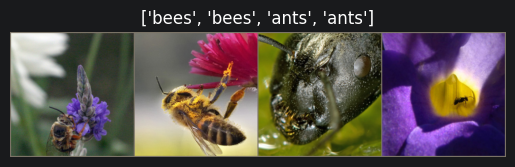

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision


def imshow(inp: torch.Tensor, title: list[str] | None = None) -> None:
    """Show a normalized image tensor as a regular image."""
    image = inp.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)

    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.axis("off")


inputs, labels = next(iter(dataloaders["train"]))
grid = torchvision.utils.make_grid(inputs)

imshow(grid, title=[class_names[label] for label in labels])

## 5. Set up loss, optimizer, and learning-rate scheduler

`CrossEntropyLoss` works for classification with two or more mutually exclusive classes. Here VGG19's replacement final layer outputs two raw scores: one for `ants` and one for `bees`; the target label is the correct class index, `0` or `1`.

The scheduler is not strictly needed for this tiny learning run. We include `StepLR` to follow the official tutorial pattern and to show the common idea of taking larger learning steps early, then smaller steps later. With `step_size=7`, a run shorter than 7 epochs will keep the learning rate unchanged.


In [17]:
import torch.optim as optim
from torch.optim import lr_scheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# CrossEntropyLoss compares raw class scores against class-index labels.
# With two classes, each image gets two scores: [ant_score, bee_score].
loss_fn = nn.CrossEntropyLoss()

trainable_parameters = [parameter for name, parameter in model.named_parameters() if parameter.requires_grad]

optimizer = optim.SGD(trainable_parameters, lr=0.001, momentum=0.9)

# StepLR is a learning-rate speed control from the official tutorial.
# step_size=7 means: wait 7 epochs before changing the learning rate.
# gamma=0.1 means: multiply the learning rate by 0.1 at each scheduled drop.
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print(f"Using device: {device}")
print(f"Trainable parameter tensors: {len(trainable_parameters)}")

Using device: cuda
Trainable parameter tensors: 2
